In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import joblib

model_path = "/content/drive/MyDrive/lda_erd_model.pkl"

lda_loaded = joblib.load(model_path)

print("Model loaded successfully.")

Model loaded successfully.


In [3]:
lda_loaded

LinearDiscriminantAnalysis()

In [4]:
import os

base_path = "/content/drive/MyDrive/files"

folders = [f for f in os.listdir(base_path) if f.startswith("S")]

filenumber = ['03']
data = []

for folder in sorted(folders):
    folder_path = os.path.join(base_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    for f in files:
        if f.lower().endswith(".edf"):

            run_part = f.split("R")[-1].split(".")[0]

            if run_part in filenumber:
                full_path = os.path.join(folder_path, f)
                data.append(full_path)

# Print final single list
print(data)
print("\nTotal files:", len(data))


['/content/drive/MyDrive/files/S071/S071R03.edf', '/content/drive/MyDrive/files/S072/S072R03.edf', '/content/drive/MyDrive/files/S074/S074R03.edf', '/content/drive/MyDrive/files/S076/S076R03.edf', '/content/drive/MyDrive/files/S077/S077R03.edf', '/content/drive/MyDrive/files/S078/S078R03.edf', '/content/drive/MyDrive/files/S079/S079R03.edf', '/content/drive/MyDrive/files/S080/S080R03.edf', '/content/drive/MyDrive/files/S081/S081R03.edf', '/content/drive/MyDrive/files/S082/S082R03.edf', '/content/drive/MyDrive/files/S083/S083R03.edf', '/content/drive/MyDrive/files/S084/S084R03.edf', '/content/drive/MyDrive/files/S085/S085R03.edf', '/content/drive/MyDrive/files/S086/S086R03.edf', '/content/drive/MyDrive/files/S087/S087R03.edf', '/content/drive/MyDrive/files/S088/S088R03.edf', '/content/drive/MyDrive/files/S089/S089R03.edf', '/content/drive/MyDrive/files/S090/S090R03.edf', '/content/drive/MyDrive/files/S091/S091R03.edf', '/content/drive/MyDrive/files/S092/S092R03.edf', '/content/drive/MyD

In [6]:
reqdata=data[0]

<RawEDF | S071R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Using matplotlib as 2D backend.


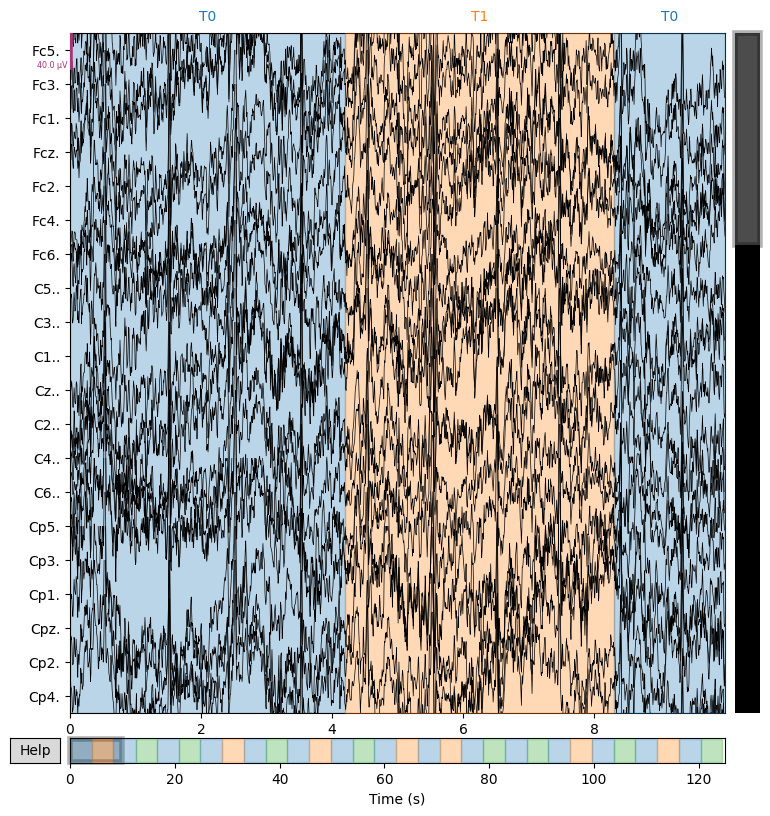

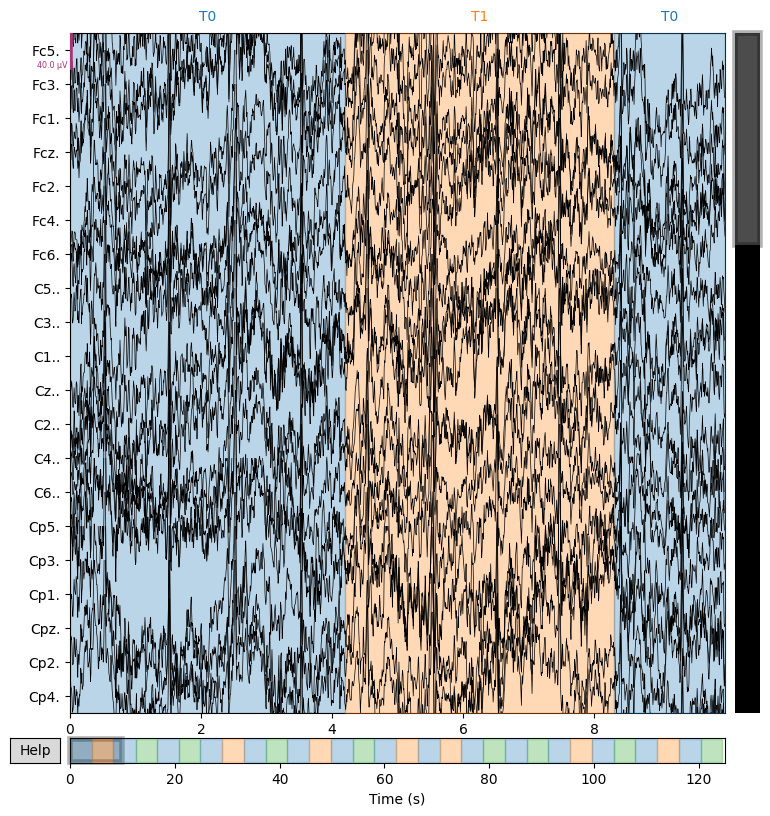

In [8]:
!pip install mne
import mne

file_path = reqdata

raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

print(raw)
raw.plot()

In [56]:
from scipy.signal import firwin, filtfilt

fs = raw.info['sfreq']

numtaps = 81   # SAFE for 4-sec window

b = firwin(
    numtaps,
    [8, 30],
    pass_zero=False,
    fs=fs
)

def fir_bandpass(signal):
    return filtfilt(b, [1.0], signal, axis=1)

In [60]:
import time

fs = raw.info['sfreq']
one_sec = int(fs)
four_sec = int(4 * fs)

total_samples = raw.n_times

baseline_var = None
buffer = []

for i in range(0, total_samples, one_sec):

    # Get 1 sec chunk
    chunk = raw.get_data(start=i, stop=i+one_sec)

    if chunk.shape[1] < one_sec:
        break

    # Average reference per second
    chunk = chunk - np.mean(chunk, axis=0, keepdims=True)
    buffer.append(chunk)

    # print("Collected 1 sec")
    # time.sleep(1)

    # When 4 sec collected
    if len(buffer) == 4:
        block = np.hstack(buffer)   # (channels, 4*fs)
        filtered = fir_bandpass(block)
        # Variance
        var_block = np.var(filtered, axis=1)

        if baseline_var is None:
            baseline_var = var_block
            # print("Baseline computed\n")
        else:
            ERD_block = (var_block - baseline_var) / baseline_var
            pred = lda_loaded.predict(ERD_block.reshape(1, -1))
            print("Prediction:", pred[0], "\n")

        buffer = []

Prediction: 2 

Prediction: 0 

Prediction: 2 

Prediction: 0 

Prediction: 0 

Prediction: 1 

Prediction: 0 

Prediction: 2 

Prediction: 1 

Prediction: 0 

Prediction: 0 

Prediction: 1 

Prediction: 0 

Prediction: 1 

Prediction: 1 

Prediction: 1 

Prediction: 0 

Prediction: 1 

Prediction: 1 

Prediction: 1 

Prediction: 0 

Prediction: 1 

Prediction: 0 

Prediction: 1 

Prediction: 2 

Prediction: 2 

Prediction: 0 

Prediction: 1 

Prediction: 0 

Prediction: 0 



In [20]:
total_samples = raw.n_times
print("Total samples:", total_samples)

Total samples: 20000
